# 02 - Kaplan-Meier curves and the log-rank test

In this notebook the event is **activation**, not churn.

That means the survival curve answers:

> What fraction of users have not activated yet by day t?

This is a useful trick. Survival analysis is not only for bad events. It is for any event where timing matters.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

def find_intro_dir():
    cwd = Path.cwd()
    if cwd.name == "survival-analysis-intro":
        return cwd
    if cwd.name == "notebooks" and cwd.parent.name == "survival-analysis-intro":
        return cwd.parent
    candidate = cwd / "survival-analysis-intro"
    if candidate.exists():
        return candidate
    return cwd

INTRO_DIR = find_intro_dir()
DATA_DIR = INTRO_DIR / "data"
OUTPUT_DIR = INTRO_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

In [2]:
activation = pd.read_csv(DATA_DIR / "product_activation_survival.csv")
activation.head()

,user_id,onboarding_path,signup_device,team_size,invited_teammates,first_week_actions,time_to_activation_days,activated_observed,followup_days
0,U0001,Guided Setup,Desktop,department,4,6,5,1,41
1,U0002,Guided Setup,Mobile,small_team,1,2,30,0,30
2,U0003,Self Serve,Mobile,solo,0,2,1,1,28
3,U0004,Self Serve,Mobile,solo,0,1,10,1,45
4,U0005,Self Serve,Mobile,solo,0,3,12,1,36


In [3]:
activation.describe(include="all").T[["count", "unique", "top", "mean", "min", "max"]]

,count,unique,top,mean,min,max
user_id,900,900,U0001,NaN,NaN,NaN
onboarding_path,900,3,Self Serve,NaN,NaN,NaN
signup_device,900,2,Desktop,NaN,NaN,NaN
team_size,900,3,solo,NaN,NaN,NaN
invited_teammates,900.0,NaN,NaN,1.824444,0.0,13.0
first_week_actions,900.0,NaN,NaN,5.16,0.0,15.0
time_to_activation_days,900.0,NaN,NaN,11.564444,1.0,45.0
activated_observed,900.0,NaN,NaN,0.931111,0.0,1.0
followup_days,900.0,NaN,NaN,36.388889,28.0,45.0


## Overall activation curve

If `S(14) = 0.35`, read it as:

> Around 35% of users have not activated by day 14.

The cumulative event curve is `1 - S(t)`, or the fraction activated by time `t`.

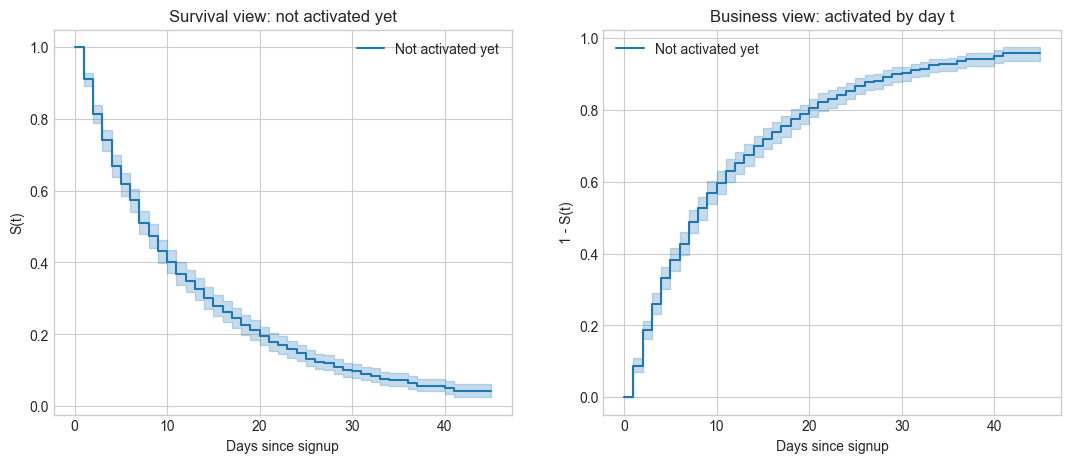

,day,not_activated_yet,activated_by_day
0,7,0.511,0.489
1,14,0.301,0.699
2,21,0.178,0.822
3,30,0.098,0.902


In [4]:
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()
kmf.fit(
    activation["time_to_activation_days"],
    event_observed=activation["activated_observed"],
    label="Not activated yet",
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
kmf.plot_survival_function(ax=axes[0])
axes[0].set_title("Survival view: not activated yet")
axes[0].set_xlabel("Days since signup")
axes[0].set_ylabel("S(t)")

kmf.plot_cumulative_density(ax=axes[1])
axes[1].set_title("Business view: activated by day t")
axes[1].set_xlabel("Days since signup")
axes[1].set_ylabel("1 - S(t)")
plt.show()

pd.DataFrame({
    "day": [7, 14, 21, 30],
    "not_activated_yet": kmf.survival_function_at_times([7, 14, 21, 30]).values.round(3),
    "activated_by_day": (1 - kmf.survival_function_at_times([7, 14, 21, 30]).values).round(3),
})

## Segment curves

A single curve tells us the average story. Segment curves ask whether different groups travel through time differently.

Here we compare onboarding paths. This is not a causal claim yet. It is a descriptive survival comparison.

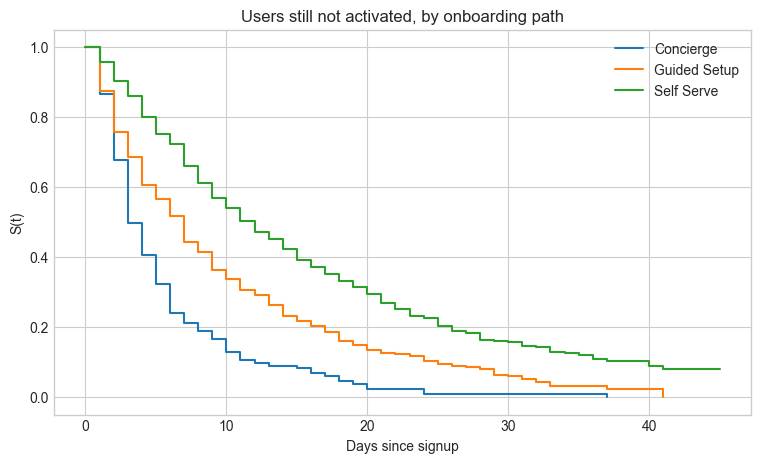

,onboarding_path,n_users,activation_rate_observed,median_days_to_activation,not_activated_day_14
0,Concierge,133,1.000000,3.0,0.090226
1,Guided Setup,341,0.961877,7.0,0.231672
2,Self Serve,426,0.884977,12.0,0.422535


In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
summary_rows = []

for path_name, group in activation.groupby("onboarding_path"):
    model = KaplanMeierFitter()
    model.fit(
        group["time_to_activation_days"],
        event_observed=group["activated_observed"],
        label=path_name,
    )
    model.plot_survival_function(ax=ax, ci_show=False)
    summary_rows.append(
        {
            "onboarding_path": path_name,
            "n_users": len(group),
            "activation_rate_observed": group["activated_observed"].mean(),
            "median_days_to_activation": model.median_survival_time_,
            "not_activated_day_14": float(model.survival_function_at_times(14).iloc[0]),
        }
    )

ax.set_title("Users still not activated, by onboarding path")
ax.set_xlabel("Days since signup")
ax.set_ylabel("S(t)")
plt.show()

pd.DataFrame(summary_rows).sort_values("not_activated_day_14")

## Log-rank test

The log-rank test asks:

> Are these curves more different than we would expect from sampling noise?

It does not tell us the size of the business opportunity by itself. For that, pair it with a table like the one above.

In [6]:
from lifelines.statistics import multivariate_logrank_test

result = multivariate_logrank_test(
    event_durations=activation["time_to_activation_days"],
    groups=activation["onboarding_path"],
    event_observed=activation["activated_observed"],
)
result.summary

,test_statistic,p,-log2(p)
0,132.730319,1.506529e-29,95.744687


In [7]:
# A practical activation backlog table for an operations or growth team.
backlog = []
for path_name, group in activation.groupby("onboarding_path"):
    model = KaplanMeierFitter().fit(
        group["time_to_activation_days"],
        group["activated_observed"],
        label=path_name,
    )
    for day in [7, 14, 21, 30]:
        not_yet = float(model.survival_function_at_times(day).iloc[0])
        backlog.append(
            {
                "onboarding_path": path_name,
                "day": day,
                "expected_not_activated_users_per_1000": round(1000 * not_yet),
            }
        )

pd.DataFrame(backlog).pivot(index="day", columns="onboarding_path", values="expected_not_activated_users_per_1000")

onboarding_path,Concierge,Guided Setup,Self Serve
day,,,
7,211,443,660
14,90,232,423
21,23,126,268
30,8,60,156


## Consultant translation

A good recommendation is not "the p-value is small."

A useful recommendation sounds more like:

> Self-serve users remain unactivated much longer. By day 14, the expected unactivated backlog is materially higher than for guided setup. If activation is valuable, prioritize a day-3 or day-7 assist for self-serve users and measure the lift in a randomized experiment.

Survival analysis gives the timing. Product judgment decides the intervention.